In [18]:
import numpy as np
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
import random
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import umap
import pandas as pd
from numpy import inf
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score

In [19]:
import opfython.math.general as g
import opfython.stream.parser as p
import opfython.stream.splitter as s
from opfython.models import SupervisedOPF
from opfython.stream import loader
from opfython.utils import logging

Load Dataset

In [20]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'../data/data_temp/cacao.csv')
df_algarrobo = pd.read_csv(r'../data/data_temp/algarrobo.csv')
covering_array  = np.loadtxt(r'../data/coveringArray.csv', delimiter=",", dtype=int)

df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())

algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]
X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())

C:\Users\salvador.romomacias\AppData\Local\Temp\ipykernel_2888\3120085030.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])


In [21]:
def cafs(ca,dataset_x,dataset_y, max_iter ,model,print_logs=False):

  global_data_set = dataset_x
  global_max = 0
  max_iteartion = 0
  result_list_x = []
  result_list_y = []
  result_list_score = []
  num_rows = ca.shape[0]

  if len(dataset_x.columns) < ca.shape[1] :
    num_colums = len(dataset_x.columns)
  else:
    num_colums = ca.shape[1]

  initialTestTraining(result_list_score,result_list_x, result_list_y,dataset_x, dataset_y,model)
  while max_iteartion < max_iter:

     lst_headers = global_data_set.columns.values.copy()
     max_score = 0.0
     mx_data_set = None
     #random.shuffle(lst_headers)
    
     for i in range(0,num_rows):
        lst_headers_to_select = []
        for j in range(0,num_colums ):
          if ca[i][j] == 1 :
              lst_headers_to_select.append(lst_headers[j])
        #with the list of headers to select get sub dat set of col with pandas
        if len(lst_headers_to_select) == 0:
            continue
        df_temp = dataset_x[lst_headers_to_select]
        x_train_temp, x_test_temp, y_train_temp, y_test_temp = train_test_split(dataset_x[lst_headers_to_select].values, dataset_y.values.ravel(),test_size=0.20,random_state=42)
        #train a model
        learning_alg = train_model(model)
        learning_alg.fit(x_train_temp, y_train_temp)
        y_pred = learning_alg.predict(x_test_temp)
        #get accuracy
        score = f1_score(y_test_temp, y_pred,average='macro')
        # if accuracy is better than maxScore so far assing subDataSet  to local_sub_data_set
        if score >= max_score :
            max_score = score
            mx_data_set = df_temp.copy()

     global_data_set = mx_data_set.copy()
     global_max = max_score
     if print_logs:
         print(f"best f1 score= {global_max}, iteration:{max_iteartion}, numbers features selected ={len(global_data_set.columns)},best features selected={', '.join(global_data_set)}" )

     num_colums  = len(global_data_set.columns)
     mx_data_set = None
     max_score = 0
     max_iteartion = max_iteartion  +1
     result_list_x.append(max_iteartion)
     result_list_y.append(len(global_data_set.columns))
     result_list_score.append(global_max)
  return result_list_x,result_list_y,result_list_score

def initialTestTraining(score_list, iter_list, feature_list ,X,y,model):
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X.values, y.values.ravel(), test_size=0.20, random_state=42)
    clf_new = train_model(model)
    clf_new.fit(X_train_temp, y_train_temp)
    y_pred = clf_new.predict(X_test_temp)
    score_list.append(f1_score(y_test_temp, y_pred,average='macro'))
    feature_list.append(X.shape[1])
    iter_list.append(0)

def train_model(model_name='ComplementNB'):  
    m = eval(model_name)
    return m

In [22]:
def  plot_results_for_covering_array(scores,feature,num_of_iterarion, path_to_save_image):
        color = 'tab:blue'
        res_scores = np.array(scores)
        res_features = np.array(feature)
        res_iter = np.array(num_of_iterarion)

        plt.figure(figsize=(11, 10))
        
        fig, ax1 = plt.subplots()
        barwidth = 0.4
        color = 'tab:red'
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Number of features', color=color)
        #ax1.set_title("ICAFS Feature selection on the Cacao dataset")
        ax1.spines['top'].set_visible(False)
        ax1.bar(res_iter-0.2, res_features, color=color, width=barwidth)
        ax1.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax1.set_ylim(1,max(res_features)+3)
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
        #for i in range(len(res_iter)):
        #    ax1.text(i+1-0.2,    res_features[i], res_features[i],rotation='vertical')
        for bar in ax1.patches:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height}', fontsize=10,
                    ha='center', va='bottom', rotation=90)
            
        ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
        color = 'tab:blue'
        ax2.set_ylabel('F1_score', color=color)
        ax2.bar(res_iter+0.2, res_scores, color=color, width=barwidth)
        ax2.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax2.set_ylim(min(res_scores)-0.001, max(res_scores)+0.001)

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        #for i in range(len(res_iter)):
        #    ax2.text(i+1, res_scores[i], f"{res_scores[i]:.3f}",rotation='vertical')

        for bar in ax2.patches:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height:.2f}', fontsize=10,
                    ha='center', va='bottom', rotation=90)

        #plt.title('ICAFS Feature selection for Cacao Dataset with OPF', y=-0.20)
        plt.gca().set_frame_on(False)
        plt.savefig(path_to_save_image)

CAFS KNN

best f1 score= 0.8982138572125701, iteration:0, numbers features selected =698,best features selected=1100, 1102, 1103, 1105, 1106, 1107, 1108, 1109, 1111, 1113, 1115, 1116, 1119, 1122, 1123, 1127, 1128, 1130, 1134, 1135, 1136, 1139, 1140, 1143, 1145, 1149, 1150, 1151, 1153, 1154, 1158, 1161, 1164, 1165, 1167, 1168, 1170, 1175, 1177, 1179, 1182, 1184, 1185, 1191, 1192, 1196, 1198, 1199, 1203, 1205, 1206, 1207, 1210, 1211, 1212, 1213, 1214, 1216, 1218, 1219, 1221, 1223, 1225, 1226, 1227, 1228, 1230, 1233, 1236, 1237, 1239, 1240, 1242, 1243, 1244, 1247, 1251, 1252, 1253, 1255, 1257, 1258, 1261, 1262, 1266, 1267, 1268, 1270, 1273, 1274, 1275, 1278, 1280, 1281, 1284, 1286, 1288, 1294, 1297, 1302, 1303, 1304, 1306, 1307, 1310, 1312, 1313, 1314, 1315, 1320, 1321, 1322, 1326, 1329, 1331, 1332, 1333, 1336, 1337, 1342, 1343, 1345, 1346, 1347, 1348, 1353, 1355, 1356, 1358, 1359, 1360, 1361, 1362, 1366, 1367, 1368, 1370, 1371, 1375, 1378, 1386, 1387, 1390, 1392, 1393, 1403, 1405, 1407, 1411, 1413

<Figure size 1100x1000 with 0 Axes>

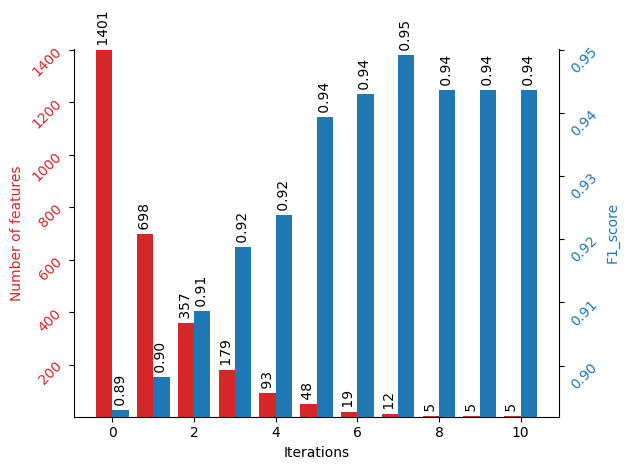

In [23]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_cacao,y_cacao,10,'KNeighborsClassifier(n_neighbors=2)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cacao_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

CAFS CACAO 5 CV KNN

In [24]:
clf = KNeighborsClassifier(n_neighbors=2)
X = X_cacao[['1225', '1322', '1559', '1936', '2296']]
res = cross_val_score(clf,X.values, y_cacao.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Cacao nibs mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )


5-CV Cacao nibs mean:0.8898103405996503 , 5-CV Cacao STD:0.03872338489656249


best f1 score= 0.7892412685668406, iteration:0, numbers features selected =11,best features selected=Edge Red, EXG, EXGR, NGBDI, RGRI, GBRI, MGRVI, NDVI, RVI, DVI, EVI
best f1 score= 0.7837837837837838, iteration:1, numbers features selected =8,best features selected=EXG, EXGR, RGRI, MGRVI, NDVI, RVI, DVI, EVI
best f1 score= 0.80389692017599, iteration:2, numbers features selected =5,best features selected=EXGR, MGRVI, RVI, DVI, EVI
best f1 score= 0.80389692017599, iteration:3, numbers features selected =5,best features selected=EXGR, MGRVI, RVI, DVI, EVI
best f1 score= 0.80389692017599, iteration:4, numbers features selected =5,best features selected=EXGR, MGRVI, RVI, DVI, EVI
best f1 score= 0.80389692017599, iteration:5, numbers features selected =5,best features selected=EXGR, MGRVI, RVI, DVI, EVI
best f1 score= 0.80389692017599, iteration:6, numbers features selected =5,best features selected=EXGR, MGRVI, RVI, DVI, EVI
best f1 score= 0.80389692017599, iteration:7, numbers features 

<Figure size 1100x1000 with 0 Axes>

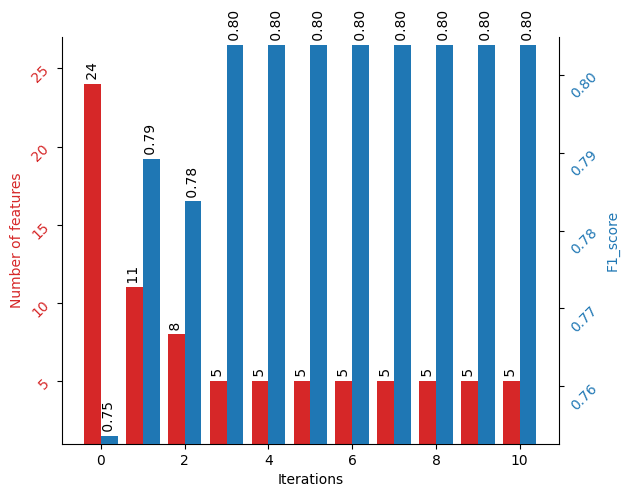

In [25]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_algarrobo,y_algarrobo,10,'KNeighborsClassifier(n_neighbors=2)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\algarrobo_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

CAFS ALGARROBO KNN 5 CV

In [26]:
clf = KNeighborsClassifier(n_neighbors=2)
X = X_algarrobo[['EXGR', 'MGRVI', 'RVI', 'DVI', 'EVI']]
res = cross_val_score(clf,X.values, y_algarrobo.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Algarrobo nibs mean:{res.mean()} , 5-CV Algarrobo STD:{res.std()}" )

5-CV Algarrobo nibs mean:0.7085583648605762 , 5-CV Algarrobo STD:0.022756729555399386


In [27]:

umap_3d = umap.UMAP(n_components=3)

c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


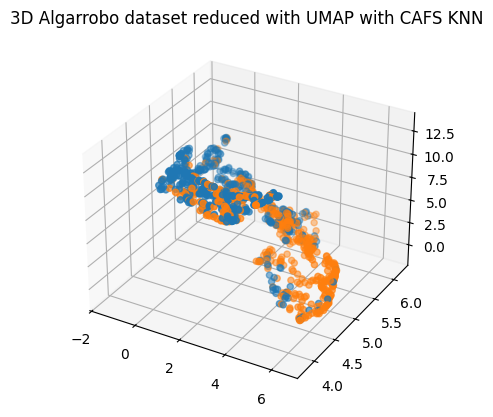

In [28]:

from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


X_reduced_algarrobo =  algarrobo_x[['EXGR', 'MGRVI', 'RVI', 'DVI', 'EVI']]
X_reduced_standarized = StandardScaler().fit_transform(X_reduced_algarrobo)
algarrobo_umap_3d_reduced = umap_3d.fit_transform(X_reduced_standarized)

fig = plt.figure()
 
# syntax for 3-D projection
ax = plt.axes(projection ='3d')
 
# defining all 3 axis
z = algarrobo_umap_3d_reduced[:,0]
x = algarrobo_umap_3d_reduced[:,1]
y = algarrobo_umap_3d_reduced[:,2]

#plt.savefig(path_to_save_image)
# plotting
ax.scatter(x, y, z, c=[sns.color_palette()[x] for x in df_algarrobo.Labels.map({"N":0, "P":1})])
ax.set_title('3D Algarrobo dataset reduced with UMAP with CAFS KNN')
plt.savefig( r'.\\output_images\\umap_.cafs_knn.png')

best f1 score= 0.9699985299279665, iteration:0, numbers features selected =6,best features selected=X, Y, X10, X20, Y30, Y40
best f1 score= 0.9864987815150317, iteration:1, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9889984157718712, iteration:2, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9889984157718712, iteration:3, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9889984157718712, iteration:4, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9889984157718712, iteration:5, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9889984157718712, iteration:6, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9889984157718712, iteration:7, numbers features selected =2,best features selected=X, Y
best f1 score= 0.9889984157718712, iteration:8, numbers features selected =2,best features selected=X, Y
best f1 score= 0.98899841

<Figure size 1100x1000 with 0 Axes>

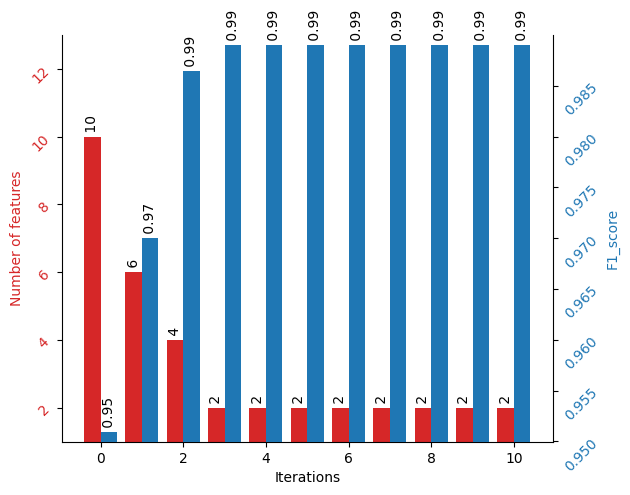

In [29]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_cis,y_cis,10,'KNeighborsClassifier(n_neighbors=2)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cis_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

CAFS CIS KNN 5 CV

In [30]:
clf = KNeighborsClassifier(n_neighbors=2)
X = X_cis[['X', 'Y']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS nibs mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )

5-CV CIS nibs mean:0.9834965165564842 , 5-CV CIS STD:0.0015821388663239812


CAFS OPF

2025-03-08 23:26:27,137 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-08 23:26:27,139 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-08 23:26:27,140 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-08 23:26:27,140 - opfython.core.opf — INFO — Class created.
2025-03-08 23:26:27,142 - opfython.models.supervised — INFO — Class overrided.
2025-03-08 23:26:27,143 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-08 23:26:27,144 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-08 23:26:27,448 - opfython.models.supervised — DEBUG — Prototypes: [638, 406, 206, 164, 596, 464, 188, 265, 504, 521, 195, 729, 320, 149, 395, 28, 261, 38, 256, 266, 632, 69, 359, 517, 51, 170, 644, 444, 426, 383, 696, 686, 693, 567, 424, 319, 397, 507, 85, 510, 654, 461, 791, 668, 289, 416, 605, 641, 457, 664, 280, 427, 283, 617, 220, 4, 75, 328, 749, 59, 401, 734, 493, 481, 3

<Figure size 1100x1000 with 0 Axes>

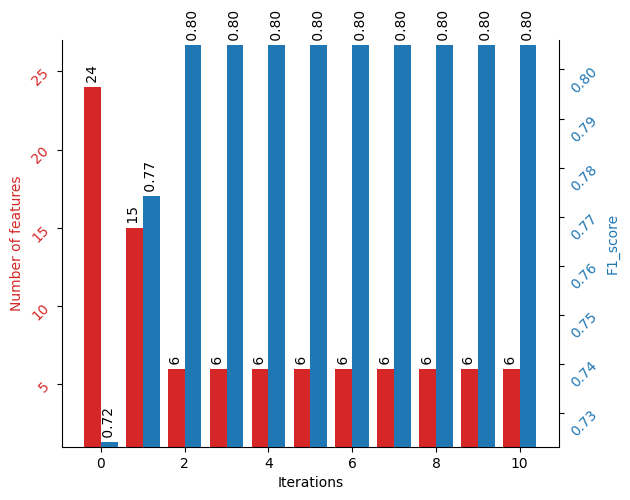

In [31]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_algarrobo,y_algarrobo,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\algarrobo_opf_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

2025-03-08 23:33:27,691 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-08 23:33:27,692 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-08 23:33:27,693 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-08 23:33:27,695 - opfython.core.opf — INFO — Class created.
2025-03-08 23:33:27,695 - opfython.models.supervised — INFO — Class overrided.
2025-03-08 23:33:27,696 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-08 23:33:27,700 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-08 23:33:28,384 - opfython.models.supervised — DEBUG — Prototypes: [225, 287, 653, 313, 761, 740, 366, 262, 145, 25, 285, 752, 178, 578, 515, 182, 695, 549, 123, 563, 341, 647, 325, 597, 167, 632, 37, 408, 711, 63, 45, 656, 658, 121, 163, 521, 421, 388, 109, 363, 713, 791, 483, 668, 395, 208, 156, 72, 558, 725, 398, 719, 619, 65, 299, 750, 70, 250, 426, 256, 43, 3, 624, 358, 19

<Figure size 1100x1000 with 0 Axes>

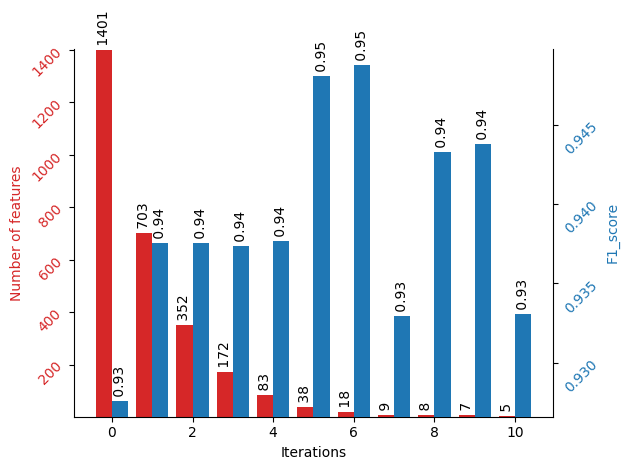

In [32]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_cacao,y_cacao,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cacao_opf_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

In [33]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_cis,y_cis,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cis_opf_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

2025-03-08 23:41:22,097 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-08 23:41:22,098 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-08 23:41:22,099 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-08 23:41:22,100 - opfython.core.opf — INFO — Class created.
2025-03-08 23:41:22,100 - opfython.models.supervised — INFO — Class overrided.
2025-03-08 23:41:22,101 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-08 23:41:22,125 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-08 23:41:48,099 - opfython.models.supervised — DEBUG — Prototypes: [199, 447, 4439, 743, 3024, 925, 5082, 3317, 3435, 7027, 1606, 1084, 5634, 3235, 1628, 5012, 7937, 422, 4560, 5781, 4329, 3637, 6881, 5426, 4785, 2674, 6732, 3847, 2064, 806, 5611, 2261, 4038, 3258, 4900, 4060, 6505, 3880, 4187, 2566, 136, 994, 3487, 7479, 6929, 794, 168, 297, 1966, 3035, 3663, 3675, 5829, 1927,

--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 74, in emit
    self.doRollover()
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 446, in doRollover
    self.rotate(self.baseFilename, dfn)
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 115, in rotate
    os.rename(source, dest)
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\salvador.romomacias\\Documents\\tesis\\icafs\\notebookes\\opfython.log' -> 'c:\\Users\\salvador.romomacias\\Documents\\tesis\\icafs\\notebookes\\opfython.log.2025-03-08'
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-pac

2025-03-09 00:00:50,524 - opfython.models.supervised — INFO — Data has been predicted.
2025-03-09 00:00:50,527 - opfython.models.supervised — INFO — Prediction time: 24.74092960357666 seconds.
2025-03-09 00:00:50,534 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-09 00:00:50,537 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-09 00:00:50,540 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-09 00:00:50,541 - opfython.core.opf — INFO — Class created.
2025-03-09 00:00:50,546 - opfython.models.supervised — INFO — Class overrided.
2025-03-09 00:00:50,550 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-09 00:00:50,573 - opfython.models.supervised — DEBUG — Finding prototypes ...


--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 74, in emit
    self.doRollover()
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 446, in doRollover
    self.rotate(self.baseFilename, dfn)
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 115, in rotate
    os.rename(source, dest)
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\salvador.romomacias\\Documents\\tesis\\icafs\\notebookes\\opfython.log' -> 'c:\\Users\\salvador.romomacias\\Documents\\tesis\\icafs\\notebookes\\opfython.log.2025-03-08'
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-pac

2025-03-09 00:01:17,785 - opfython.models.supervised — DEBUG — Prototypes: [4187, 5510, 1733, 4115, 6505, 1758, 199, 3129, 3435, 7027, 4226, 6413, 6929, 5082, 3024, 1084, 7164, 7937, 422, 7346, 192, 5764, 7501, 1606, 17, 3317, 4560, 5781, 5611, 2261, 7186, 3652, 35, 2387, 7000, 3552, 5075, 3812, 2416, 2413, 2289, 7999, 6938, 2677, 7908, 3489, 7682, 994, 5561, 4521, 4343, 5793, 1020, 3557, 4292, 4900, 7268, 7223, 5819, 4085, 437, 6512, 6881, 5426, 2290, 4785, 4287, 4119, 7585, 7745, 1774, 3095, 7759, 2990, 4718, 616, 978, 3263, 1491, 7420, 6368, 3519, 3274, 5705, 4152, 2989, 4329, 5829, 2566, 7817, 2110, 6272, 6162, 445, 7114, 2949, 3320, 7308, 4086, 4981, 7645, 2064, 1368, 7332, 3235, 1553, 4773, 5034, 1488, 6732, 7513, 3847, 2633, 3096, 5408, 3035, 1966, 2720, 2026, 1902, 5734, 7755, 1927, 3343, 47, 4267, 2157, 1063, 7242, 5709, 1290, 6907, 2146, 3532, 6706, 472, 2776, 4485, 3751, 7479, 223, 6423, 3949, 210, 4802, 1233, 6955, 2428, 7992, 5493, 1998, 1598, 6240, 3420, 2605, 1537, 3291,

...

2025-03-09 00:40:31,240 - opfython.models.supervised — INFO — Data has been predicted.
2025-03-09 00:40:31,240 - opfython.models.supervised — INFO — Prediction time: 19.71037244796753 seconds.
2025-03-09 00:40:31,256 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-09 00:40:31,256 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-09 00:40:31,256 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-09 00:40:31,256 - opfython.core.opf — INFO — Class created.
2025-03-09 00:40:31,256 - opfython.models.supervised — INFO — Class overrided.
2025-03-09 00:40:31,256 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-09 00:40:31,290 - opfython.models.supervised — DEBUG — Finding prototypes ...


--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 74, in emit
    self.doRollover()
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 446, in doRollover
    self.rotate(self.baseFilename, dfn)
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 115, in rotate
    os.rename(source, dest)
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\salvador.romomacias\\Documents\\tesis\\icafs\\notebookes\\opfython.log' -> 'c:\\Users\\salvador.romomacias\\Documents\\tesis\\icafs\\notebookes\\opfython.log.2025-03-08'
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-pac

2025-03-09 00:40:57,931 - opfython.models.supervised — DEBUG — Prototypes: [3652, 3879, 447, 1553, 1886, 595, 1591, 5137, 5861, 7332, 3155, 7479, 7682, 5205, 3812, 3243, 3024, 7501, 925, 3112, 3288, 6066, 5105, 6732, 3390, 616, 3847, 6881, 1194, 95, 4528, 470, 4785, 4038, 3641, 7000, 2195, 4560, 4939, 2633, 743, 2823, 2387, 5121, 5011, 1820, 2882, 1544, 4816, 7631, 6012, 2691, 7621, 2989, 5247, 7664, 4060, 4900, 4085, 6139, 933, 7335, 2261, 3263, 764, 7734, 6370, 1367, 6006, 875, 7407, 1362, 3663, 7584, 5012, 1435, 3276, 7346, 6057, 5328, 5051, 2290, 6462, 6731, 7223, 963, 2289, 3361, 711, 680, 3949, 6295, 5243, 4187, 1012, 2146, 7755, 6176, 4541, 3990, 491, 3557, 3721, 1057, 7962, 5501, 7937, 3591, 4181, 826, 562, 1774, 7745, 7585, 4119, 4718, 1766, 3142, 3247, 3373, 6995, 27, 1063, 7999, 1882, 7908, 2428, 4981, 1718, 1927, 5505, 5734, 578, 2776, 7963, 7645, 7735, 6031, 2554, 5408, 2157, 3667, 994, 4885, 4226, 5754, 3865, 6368, 3235, 3323, 6832, 1445, 2703, 388, 5989, 1747, 3474, 7286

--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 74, in emit
    self.doRollover()
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 446, in doRollover
    self.rotate(self.baseFilename, dfn)
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\logging\handlers.py", line 115, in rotate
    os.rename(source, dest)
PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\salvador.romomacias\\Documents\\tesis\\icafs\\notebookes\\opfython.log' -> 'c:\\Users\\salvador.romomacias\\Documents\\tesis\\icafs\\notebookes\\opfython.log.2025-03-08'
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-pac

KeyboardInterrupt: 

CAFS SVC 

Index(['1100', '1103', '1105', '1106', '1107', '1111', '1114', '1116', '1118',
       '1119',
       ...
       '2481', '2484', '2488', '2490', '2491', '2492', '2494', '2495', '2497',
       '2498'],
      dtype='object', length=699)
0.7128339435451457
____________________________
Index(['1103', '1105', '1106', '1107', '1111', '1116', '1119', '1122', '1124',
       '1137',
       ...
       '2478', '2484', '2488', '2490', '2491', '2492', '2494', '2495', '2497',
       '2498'],
      dtype='object', length=341)
0.7220620627065487
____________________________
Index(['1107', '1111', '1116', '1124', '1142', '1143', '1153', '1168', '1180',
       '1202',
       ...
       '2450', '2456', '2463', '2464', '2472', '2484', '2490', '2491', '2495',
       '2498'],
      dtype='object', length=170)
0.7310405009984883
____________________________
Index(['1111', '1116', '1142', '1143', '1153', '1202', '1223', '1236', '1242',
       '1319', '1348', '1365', '1378', '1382', '1384', '1412', '1430', '144

<Figure size 1100x1000 with 0 Axes>

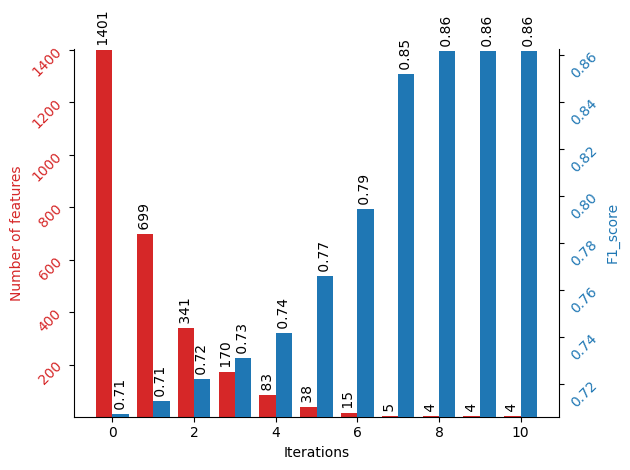

In [ ]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_cacao,y_cacao,10,'svm.SVC()',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cacao_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

CAFS SVC CACAO 5 CV

In [ ]:
clf = svm.SVC()
X = X_cacao[['1223', '1583', '1957', '2313']]
res = cross_val_score(clf,X.values, y_cacao.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CACAO nibs mean:{res.mean()} , 5-CV CACAO STD:{res.std()}" )

Index(['Edge Red', 'NGRDI', 'GBRI', 'GBRI.1', 'MGRVI', 'NDVI', 'EVI', 'REVI',
       'NDRE', 'RERVI'],
      dtype='object')
0.7849946248656217
____________________________
Index(['Edge Red', 'GBRI.1', 'NDVI', 'EVI', 'REVI'], dtype='object')
0.78997899789979
____________________________
Index(['Edge Red', 'GBRI.1', 'NDVI', 'EVI', 'REVI'], dtype='object')
0.78997899789979
____________________________
Index(['Edge Red', 'GBRI.1', 'NDVI', 'EVI', 'REVI'], dtype='object')
0.78997899789979
____________________________
Index(['Edge Red', 'GBRI.1', 'NDVI', 'EVI', 'REVI'], dtype='object')
0.78997899789979
____________________________
Index(['Edge Red', 'GBRI.1', 'NDVI', 'EVI', 'REVI'], dtype='object')
0.78997899789979
____________________________
Index(['Edge Red', 'GBRI.1', 'NDVI', 'EVI', 'REVI'], dtype='object')
0.78997899789979
____________________________
Index(['Edge Red', 'GBRI.1', 'NDVI', 'EVI', 'REVI'], dtype='object')
0.78997899789979
____________________________
Index(['Edge Red', 'GB

<Figure size 1100x1000 with 0 Axes>

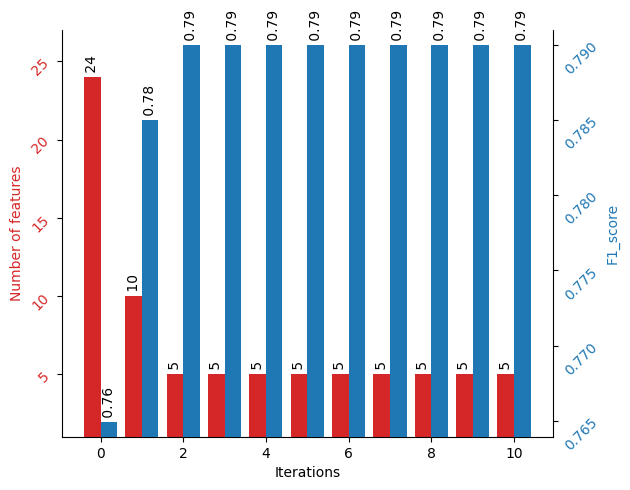

In [ ]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_algarrobo,y_algarrobo,10,'svm.SVC()',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\algarrobo_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

CAFS SVC 5 CV ALGARROBO

In [ ]:
clf = svm.SVC()
X = X_algarrobo[['Edge Red', 'GBRI.1', 'NDVI', 'EVI', 'REVI']]
res = cross_val_score(clf,X.values, y_algarrobo.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Algarrobo nibs mean:{res.mean()} , 5-CV Algarrobo STD:{res.std()}" )

Index(['X', 'Y', 'X20', 'Y20', 'X30', 'Y40'], dtype='object')
0.978999978999979
____________________________
Index(['X', 'Y', 'X30', 'Y40'], dtype='object')
0.981999837998542
____________________________
Index(['X', 'Y', 'X30', 'Y40'], dtype='object')
0.981999837998542
____________________________
Index(['X', 'Y', 'X30', 'Y40'], dtype='object')
0.981999837998542
____________________________
Index(['X', 'Y', 'X30', 'Y40'], dtype='object')
0.981999837998542
____________________________
Index(['X', 'Y', 'X30', 'Y40'], dtype='object')
0.981999837998542
____________________________
Index(['X', 'Y', 'X30', 'Y40'], dtype='object')
0.981999837998542
____________________________
Index(['X', 'Y', 'X30', 'Y40'], dtype='object')
0.981999837998542
____________________________
Index(['X', 'Y', 'X30', 'Y40'], dtype='object')
0.981999837998542
____________________________
Index(['X', 'Y', 'X30', 'Y40'], dtype='object')
0.981999837998542
____________________________
Processing time: 551.4886419773102 s

<Figure size 1100x1000 with 0 Axes>

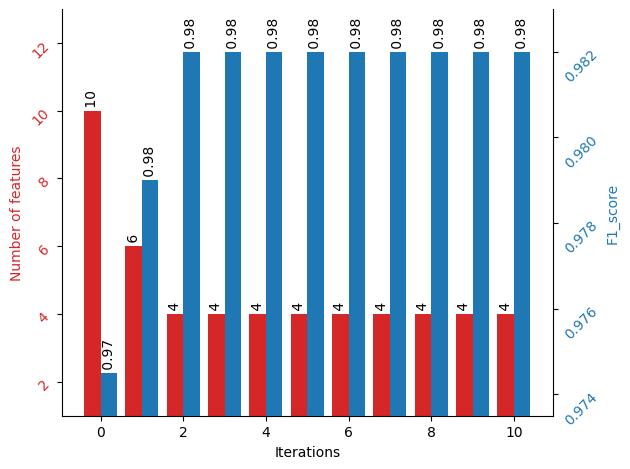

In [ ]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_cis,y_cis,10,'svm.SVC()',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cis_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

CAFS SVC CIS 5CV

In [ ]:
clf = svm.SVC()
X = X_cis[['X', 'Y', 'X30', 'Y40']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS nibs mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )

CAFS MLP

Index(['1103', '1104', '1105', '1108', '1110', '1111', '1112', '1116', '1119',
       '1121',
       ...
       '2482', '2483', '2486', '2489', '2493', '2495', '2496', '2497', '2499',
       '2500'],
      dtype='object', length=700)
0.9891919191919193
____________________________
Index(['1103', '1104', '1105', '1110', '1111', '1116', '1119', '1121', '1125',
       '1139',
       ...
       '2468', '2469', '2470', '2476', '2477', '2483', '2486', '2493', '2499',
       '2500'],
      dtype='object', length=337)
0.9746208660202997
____________________________
Index(['1104', '1105', '1111', '1116', '1119', '1121', '1125', '1142', '1155',
       '1166',
       ...
       '2400', '2419', '2433', '2450', '2457', '2466', '2469', '2470', '2476',
       '2499'],
      dtype='object', length=160)
0.9699746702326681
____________________________
Index(['1104', '1105', '1111', '1121', '1142', '1155', '1181', '1205', '1207',
       '1224', '1225', '1228', '1244', '1249', '1271', '1287', '1297', '130

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron

Index(['1105', '1121', '1155', '1181', '1205', '1207', '1244', '1297', '1304',
       '1314', '1365', '1425', '1461', '1485', '1488', '1539', '1555', '1569',
       '1571', '1591', '1617', '1659', '1661', '1662', '1700', '1708', '1715',
       '1723', '1729', '1778', '1818', '1917', '1921', '1954', '1961', '1966',
       '1970', '2006', '2008', '2022', '2051', '2053', '2099', '2101', '2142',
       '2205', '2310', '2328', '2375', '2476'],
      dtype='object')
0.9551819137128099
____________________________


d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron

Index(['1105', '1121', '1155', '1205', '1297', '1314', '1365', '1485', '1488',
       '1555', '1659', '1661', '1662', '1700', '1708', '1715', '1723', '1729',
       '1818', '1917', '1921', '1961', '2008', '2051', '2053', '2142', '2310',
       '2328', '2375', '2476'],
      dtype='object')
0.9131276163760799
____________________________


...

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron

Index(['1121', '1205', '1365', '1485', '1661', '1708', '1723', '1729', '1818',
       '1917', '1921', '2008', '2310', '2375', '2476'],
      dtype='object')
0.7846141704712912
____________________________


d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


Index(['1121', '1205', '1661', '1708', '1723', '1917', '1921', '2310', '2375',
       '2476'],
      dtype='object')
0.7609874161598299
____________________________
Index(['1121', '1205', '1661', '1917', '2310', '2375'], dtype='object')
0.6948679479901604
____________________________
Processing time: 5522.067560195923 seconds


<Figure size 1100x1000 with 0 Axes>

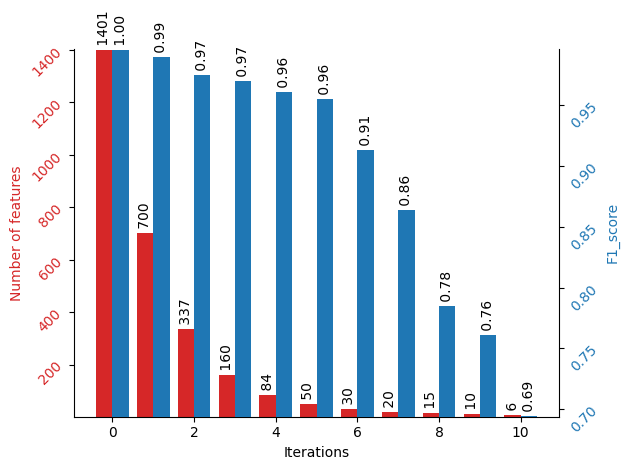

In [ ]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_cacao,y_cacao,10,'MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cacao_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

CAFS MLP CACO 5 CV

In [ ]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_cacao[['1105', '1121', '1155', '1205', '1297', '1314', '1365', '1485', '1488',
       '1555', '1659', '1661', '1662', '1700', '1708', '1715', '1723', '1729',
       '1818', '1917', '1921', '1961', '2008', '2051', '2053', '2142', '2310',
       '2328', '2375', '2476']]
res = cross_val_score(clf,X.values, y_cacao.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV cacao nibs mean:{res.mean()} , 5-CV cacao STD:{res.std()}" )

Index(['R', 'B', 'Edge Red', 'EXG', 'EXGR', 'NGRDI', 'NGBDI', 'RGRI', 'GBRI.1',
       'VEG', 'MGRVI', 'NDVI', 'EVI', 'RERVI', 'REDVI'],
      dtype='object')
0.7699769976997699
____________________________
Index(['R', 'NGRDI', 'GBRI.1', 'VEG', 'MGRVI', 'NDVI', 'REDVI'], dtype='object')
0.784865540963102
____________________________
Index(['R', 'MGRVI'], dtype='object')
0.7798018216394755
____________________________
Index(['R', 'MGRVI'], dtype='object')
0.7798018216394755
____________________________
Index(['R', 'MGRVI'], dtype='object')
0.7798018216394755
____________________________
Index(['R', 'MGRVI'], dtype='object')
0.7798018216394755
____________________________
Index(['R', 'MGRVI'], dtype='object')
0.7798018216394755
____________________________
Index(['R', 'MGRVI'], dtype='object')
0.7798018216394755
____________________________
Index(['R', 'MGRVI'], dtype='object')
0.7798018216394755
____________________________
Index(['R', 'MGRVI'], dtype='object')
0.7798018216394755
______

<Figure size 1100x1000 with 0 Axes>

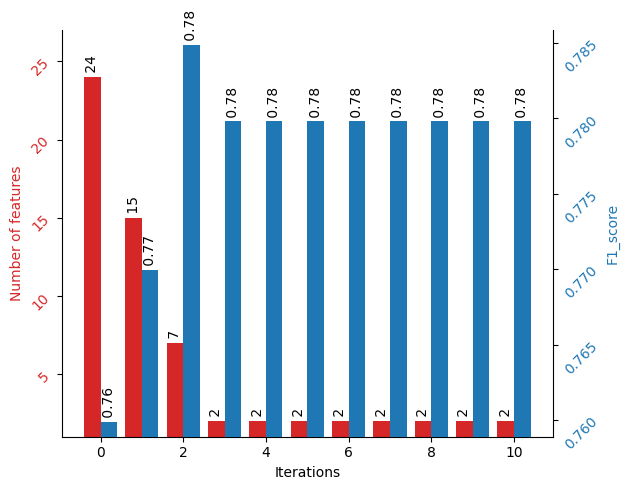

In [ ]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_algarrobo,y_algarrobo,10,'MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\algarrobo_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

CAFS MLP ALGARROBO 5 CV

In [ ]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_algarrobo[['R', 'NGRDI', 'GBRI.1', 'VEG', 'MGRVI', 'NDVI', 'REDVI']]
res = cross_val_score(clf,X.values, y_algarrobo.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Algarrobo mean:{res.mean()} , 5-CV Algarrobo STD:{res.std()}" )

Index(['X', 'Y', 'X10', 'X20', 'Y30', 'Y40'], dtype='object')
0.960499753123457
____________________________
Index(['X', 'Y', 'X10', 'X20', 'Y30', 'Y40'], dtype='object')
0.960999960999961
____________________________
Index(['X', 'Y', 'Y30', 'Y40'], dtype='object')
0.960499753123457
____________________________
Index(['X', 'Y', 'Y30', 'Y40'], dtype='object')
0.960999843999376
____________________________
Index(['X', 'Y', 'Y30', 'Y40'], dtype='object')
0.961999961999962
____________________________
Index(['X', 'Y', 'Y30', 'Y40'], dtype='object')
0.9604992001088022
____________________________
Index(['X', 'Y', 'Y30', 'Y40'], dtype='object')
0.9579984879455661
____________________________
Index(['X', 'Y', 'Y30', 'Y40'], dtype='object')
0.9579998319993279
____________________________
Index(['X', 'Y', 'Y30', 'Y40'], dtype='object')
0.962999962999963
____________________________
Index(['X', 'Y', 'Y30', 'Y40'], dtype='object')
0.9594999898749974
____________________________
Processing time: 3

<Figure size 1100x1000 with 0 Axes>

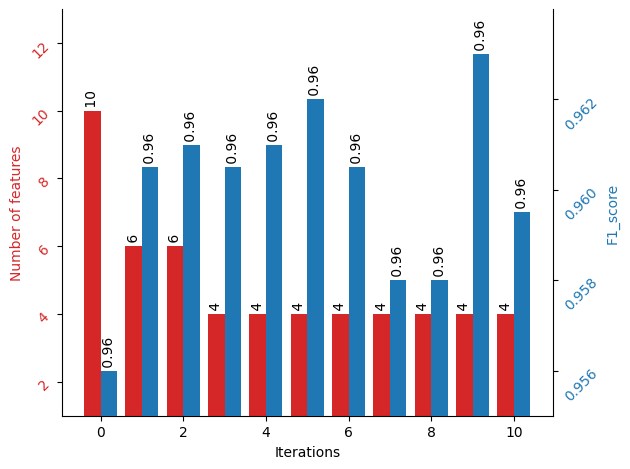

In [ ]:
start_time = time.time()
iterarions,features,scores = cafs(covering_array,X_cis,y_cis,10,'MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)',True)
plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cis_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

CAFS CIS MLP 5CV

In [ ]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_cis[['X', 'Y', 'Y30', 'Y40']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )